# Notebook 06 — Structural Cluster Evaluation

Evaluate and compare candidate clustering models developed from the U.S. structural population dataset derived from ACS PUMS.

## Objectives

- Compare clustering approaches: **K-Modes**, **K-Prototypes**, and **MCA + K-Means**
- Assess cluster quality using quantitative diagnostics and interpretability
- Estimate weighted cluster sizes using **PWGTP** survey weights
- Profile clusters across key structural demographic and socioeconomic features

## Outcome

Select the structural segmentation model that best balances statistical quality, interpretability, and population representativeness.  
The selected clustering model will serve as the foundation for downstream segment interpretation and audience archetype development.

In [5]:
# Environment setup
# Core libraries
from pathlib import Path
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model loading
import joblib

# Clustering metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Plot style
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

In [6]:
# -------------------------------------------------------------------
# Paths and file locations
# -------------------------------------------------------------------

from pathlib import Path

# Project root (works when running notebooks from /notebooks)
PROJECT_ROOT = Path.cwd().parent

# Core directories
DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"

MODELS_DIR = PROJECT_ROOT / "models" / "clustering"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "tables"

# -------------------------------------------------------------------
# Structural population dataset (from Notebook 04)
# -------------------------------------------------------------------

STRUCTURAL_PATH = INTERIM_DIR / "acs_pums_5y" / "us_structural_population_v1.parquet"

# -------------------------------------------------------------------
# Clustering experiment results (from Notebook 05)
# -------------------------------------------------------------------

EXPERIMENT_RESULTS_PATH = OUTPUTS_DIR / "clustering_experiment_results.csv"

# -------------------------------------------------------------------
# Candidate model files
# -------------------------------------------------------------------

kmodes_models = sorted(MODELS_DIR.glob("kmodes_k*.joblib"))
kprototypes_models = sorted(MODELS_DIR.glob("kprototypes_k*.joblib"))
mca_kmeans_models = sorted(MODELS_DIR.glob("mca_kmeans_k*.joblib"))

# -------------------------------------------------------------------
# Diagnostics
# -------------------------------------------------------------------

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STRUCTURAL_PATH exists:", STRUCTURAL_PATH.exists())
print("Experiment results exists:", EXPERIMENT_RESULTS_PATH.exists())

print("\nK-Modes models found:", len(kmodes_models))
print("K-Prototypes models found:", len(kprototypes_models))
print("MCA + K-Means models found:", len(mca_kmeans_models))

print("\nExample files:")
print("K-Modes:", kmodes_models[:2])
print("K-Prototypes:", kprototypes_models[:2])
print("MCA + K-Means:", mca_kmeans_models[:2])

PROJECT_ROOT: /Users/marcomagnolo/Projects/us-audience-segmentation
STRUCTURAL_PATH exists: True
Experiment results exists: True

K-Modes models found: 12
K-Prototypes models found: 12
MCA + K-Means models found: 12

Example files:
K-Modes: [PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kmodes_k10.joblib'), PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kmodes_k11.joblib')]
K-Prototypes: [PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kprototypes_k10.joblib'), PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kprototypes_k11.joblib')]
MCA + K-Means: [PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/mca_kmeans_k10.joblib'), PosixPath('/Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/mca_kmeans_k11.joblib')]


In [7]:
# Load structural dataset
df_population = pd.read_parquet(STRUCTURAL_PATH)

# Load clustering experiment summary
df_results = pd.read_csv(EXPERIMENT_RESULTS_PATH)

print("Structural dataset shape:", df_population.shape)
print("Experiment results shape:", df_results.shape)

Structural dataset shape: (1000000, 19)
Experiment results shape: (36, 4)


In [8]:
display(df_population.head())
display(df_results.head())

,serialno,sporder,pwgtp,actor_class,age_bin,sex_label,race_eth,edu_tier,emp_tier,income_tier_fixed,income_tier_pct,mar_tier,commute_tier,tenure,household_size,vehicle_count,puma,hhincome_tier,household_type
0,2023HU1043211,2,58,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Car,3,2,0,4316,0-19k,housing_unit
1,2019HU1076190,2,46,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P20-40,Never_Married,Car,3,4,2,5922,20-49k,housing_unit
2,2019GQ0046130,1,12,Adult,35-44,Male,Black_NH,HS_or_less,Other_Not_in_Labor_Force,0-19k,P0-20,Never_Married,NaN,group_quarters,1,0,11300,group_quarters,group_quarters
3,2019HU0403832,1,76,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Work_From_Home,1,5,2,2510,50-99k,housing_unit
4,2019HU0277198,1,64,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Car,3,4,1,4607,20-49k,housing_unit


,algorithm,k,cost_or_inertia,cluster_sizes
0,K-Modes,4,5909214.0,"{0: 351403, 1: 232768, 2: 257670, 3: 158159}"
1,K-Modes,5,5718394.0,"{0: 242175, 1: 198359, 2: 194221, 3: 234152, 4..."
2,K-Modes,6,5611932.0,"{0: 232985, 1: 209129, 2: 151054, 3: 208339, 4..."
3,K-Modes,7,5573280.0,"{0: 248441, 1: 177352, 2: 225828, 3: 133853, 4..."
4,K-Modes,8,5434535.0,"{0: 100035, 1: 175194, 2: 92175, 3: 180512, 4:..."


In [9]:
df_population.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   serialno           1000000 non-null  str     
 1   sporder            1000000 non-null  int64   
 2   pwgtp              1000000 non-null  int64   
 3   actor_class        1000000 non-null  str     
 4   age_bin            1000000 non-null  string  
 5   sex_label          1000000 non-null  string  
 6   race_eth           1000000 non-null  string  
 7   edu_tier           1000000 non-null  string  
 8   emp_tier           804465 non-null   str     
 9   income_tier_fixed  1000000 non-null  string  
 10  income_tier_pct    778466 non-null   str     
 11  mar_tier           1000000 non-null  string  
 12  commute_tier       473674 non-null   category
 13  tenure             1000000 non-null  string  
 14  household_size     1000000 non-null  int64   
 15  vehicle_count      1000000 

In [10]:
# inspecting cluster evaluation results
# Load experiment results
df_results = pd.read_csv(EXPERIMENT_RESULTS_PATH)

print("Shape:", df_results.shape)
display(df_results.head())

Shape: (36, 4)


,algorithm,k,cost_or_inertia,cluster_sizes
0,K-Modes,4,5909214.0,"{0: 351403, 1: 232768, 2: 257670, 3: 158159}"
1,K-Modes,5,5718394.0,"{0: 242175, 1: 198359, 2: 194221, 3: 234152, 4..."
2,K-Modes,6,5611932.0,"{0: 232985, 1: 209129, 2: 151054, 3: 208339, 4..."
3,K-Modes,7,5573280.0,"{0: 248441, 1: 177352, 2: 225828, 3: 133853, 4..."
4,K-Modes,8,5434535.0,"{0: 100035, 1: 175194, 2: 92175, 3: 180512, 4:..."


In [11]:
df_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   algorithm        36 non-null     str    
 1   k                36 non-null     int64  
 2   cost_or_inertia  36 non-null     float64
 3   cluster_sizes    36 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.1 KB


In [12]:
df_results.columns.tolist()

['algorithm', 'k', 'cost_or_inertia', 'cluster_sizes']

In [13]:
# sort by algorithm and n_clusters
df_results.sort_values(["algorithm", "k"]).head(20)

,algorithm,k,cost_or_inertia,cluster_sizes
0,K-Modes,4,5.909214e+06,"{0: 351403, 1: 232768, 2: 257670, 3: 158159}"
1,K-Modes,5,5.718394e+06,"{0: 242175, 1: 198359, 2: 194221, 3: 234152, 4..."
2,K-Modes,6,5.611932e+06,"{0: 232985, 1: 209129, 2: 151054, 3: 208339, 4..."
3,K-Modes,7,5.573280e+06,"{0: 248441, 1: 177352, 2: 225828, 3: 133853, 4..."
4,K-Modes,8,5.434535e+06,"{0: 100035, 1: 175194, 2: 92175, 3: 180512, 4:..."
5,K-Modes,9,5.364130e+06,"{0: 151698, 1: 137883, 2: 152652, 3: 96268, 4:..."
6,K-Modes,10,5.222617e+06,"{0: 194187, 1: 115758, 2: 103867, 3: 68656, 4:..."
7,K-Modes,11,5.250443e+06,"{0: 108833, 1: 149812, 2: 132166, 3: 65683, 4:..."
8,K-Modes,12,5.165516e+06,"{0: 116417, 1: 62120, 2: 100832, 3: 166634, 4:..."
9,K-Modes,13,5.071515e+06,"{0: 79218, 1: 163060, 2: 65243, 3: 141634, 4: ..."


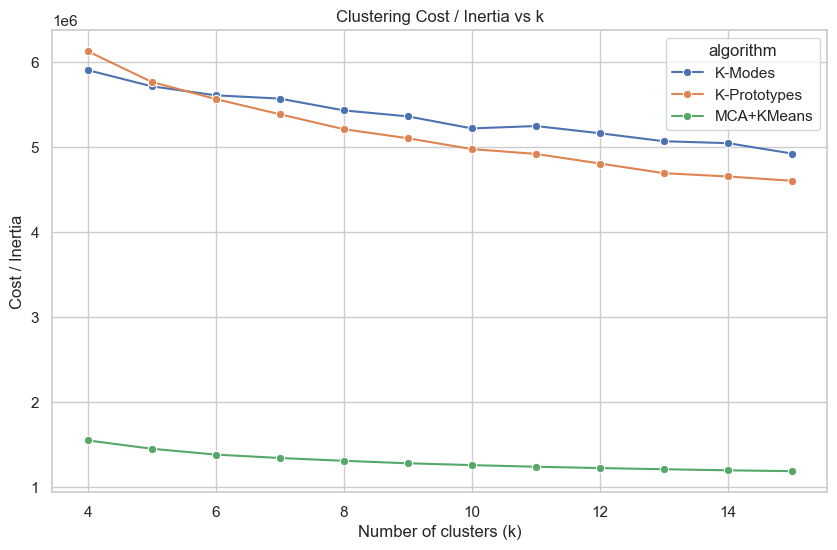

In [14]:
# visualizing model behavior
sns.lineplot(
    data=df_results,
    x="k",
    y="cost_or_inertia",
    hue="algorithm",
    marker="o"
)

plt.title("Clustering Cost / Inertia vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost / Inertia")
plt.show()

### Clustering Experiment Summary

The clustering experiments evaluated three algorithms (K-Modes, K-Prototypes, and MCA + K-Means) across a range of cluster counts from **k = 4 to k = 15**. The cost / inertia curves show a consistent decline as the number of clusters increases, with diminishing improvements after a certain point.

Across all three algorithms, the curves begin to flatten approximately between **k = 8 and k = 10**, indicating that additional clusters beyond this range provide limited gains in clustering quality. This range therefore represents the most plausible candidate region for the final segmentation.

Based on the elbow behavior observed in the curves, the most relevant values for further inspection are:

- **k = 7–8** for K-Modes  
- **k = 8–9** for K-Prototypes  
- **k = 9–10** for MCA + K-Means  

The next step is to inspect these candidate models directly by loading the corresponding trained models, assigning cluster labels, and evaluating cluster balance and interpretability before selecting the final structural segmentation.

In [15]:
# Inspecting cluster sizes
df_results[['algorithm', 'k', 'cluster_sizes']].head(12)

,algorithm,k,cluster_sizes
0,K-Modes,4,"{0: 351403, 1: 232768, 2: 257670, 3: 158159}"
1,K-Modes,5,"{0: 242175, 1: 198359, 2: 194221, 3: 234152, 4..."
2,K-Modes,6,"{0: 232985, 1: 209129, 2: 151054, 3: 208339, 4..."
3,K-Modes,7,"{0: 248441, 1: 177352, 2: 225828, 3: 133853, 4..."
4,K-Modes,8,"{0: 100035, 1: 175194, 2: 92175, 3: 180512, 4:..."
5,K-Modes,9,"{0: 151698, 1: 137883, 2: 152652, 3: 96268, 4:..."
6,K-Modes,10,"{0: 194187, 1: 115758, 2: 103867, 3: 68656, 4:..."
7,K-Modes,11,"{0: 108833, 1: 149812, 2: 132166, 3: 65683, 4:..."
8,K-Modes,12,"{0: 116417, 1: 62120, 2: 100832, 3: 166634, 4:..."
9,K-Modes,13,"{0: 79218, 1: 163060, 2: 65243, 3: 141634, 4: ..."


In [16]:
# Parsing cluster Size Dictionraries
import ast

df_results["cluster_sizes_dict"] = df_results["cluster_sizes"].apply(ast.literal_eval)

df_results[["algorithm", "k", "cluster_sizes_dict"]].head()

,algorithm,k,cluster_sizes_dict
0,K-Modes,4,"{0: 351403, 1: 232768, 2: 257670, 3: 158159}"
1,K-Modes,5,"{0: 242175, 1: 198359, 2: 194221, 3: 234152, 4..."
2,K-Modes,6,"{0: 232985, 1: 209129, 2: 151054, 3: 208339, 4..."
3,K-Modes,7,"{0: 248441, 1: 177352, 2: 225828, 3: 133853, 4..."
4,K-Modes,8,"{0: 100035, 1: 175194, 2: 92175, 3: 180512, 4:..."


In [17]:
# computing cluster metrics (smallest, biggest, size ratio)
def compute_balance_metrics(d):
    sizes = list(d.values())
    return pd.Series({
        "min_cluster": min(sizes),
        "max_cluster": max(sizes),
        "imbalance_ratio": max(sizes) / min(sizes)
    })

balance_metrics = df_results["cluster_sizes_dict"].apply(compute_balance_metrics)

df_results = pd.concat([df_results, balance_metrics], axis=1)

df_results[[
    "algorithm",
    "k",
    "min_cluster",
    "max_cluster",
    "imbalance_ratio"
]].head(12)

,algorithm,k,min_cluster,max_cluster,imbalance_ratio
0,K-Modes,4,158159.0,351403.0,2.221834
1,K-Modes,5,131093.0,242175.0,1.847353
2,K-Modes,6,74347.0,232985.0,3.133751
3,K-Modes,7,54528.0,248441.0,4.556210
4,K-Modes,8,56351.0,217190.0,3.854235
5,K-Modes,9,70735.0,152652.0,2.158083
6,K-Modes,10,23768.0,194187.0,8.170103
7,K-Modes,11,17916.0,164578.0,9.186091
8,K-Modes,12,26150.0,166634.0,6.372237
9,K-Modes,13,26878.0,163060.0,6.066672


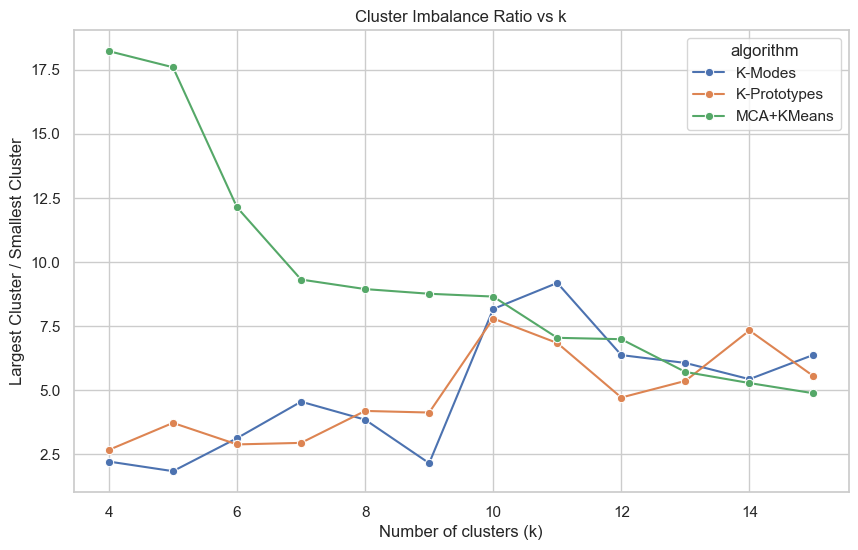

In [18]:
# visualizing imbalance ratio
sns.lineplot(
    data=df_results,
    x="k",
    y="imbalance_ratio",
    hue="algorithm",
    marker="o"
)

plt.title("Cluster Imbalance Ratio vs k")
plt.ylabel("Largest Cluster / Smallest Cluster")
plt.xlabel("Number of clusters (k)")
plt.show()

### Cluster Balance Analysis

To evaluate the structural stability of the clustering solutions, the **imbalance ratio** between the largest and smallest cluster was computed for each algorithm and number of clusters (k). The imbalance ratio is defined as:

Largest cluster size / Smallest cluster size

Lower values indicate more balanced segment distributions, while higher values suggest that the clustering solution concentrates a large portion of observations in one dominant cluster.

The results show different behaviors across algorithms:

- **K-Modes** produces relatively balanced clusters for smaller values of k, particularly between **k = 6 and k = 9**, where the imbalance ratio remains below or around 5. However, imbalance increases sharply around **k = 10–11**, indicating unstable segment structure at those values.

- **K-Prototypes** shows a similar pattern, with moderate and stable imbalance levels between **k = 6 and k = 9**. Larger k values introduce higher variability in cluster sizes.

- **MCA + K-Means** initially generates highly imbalanced clusters for small k values, suggesting that the dimensionality reduction step captures a dominant structural axis in the data. As k increases, the imbalance ratio gradually decreases, approaching acceptable levels only at higher cluster counts.

Based on this analysis, clustering solutions with an **imbalance ratio ≤ 5** were retained as viable candidates for further inspection. This threshold allows natural variation in societal segment sizes while filtering out solutions where a single cluster dominates the population.

In [19]:
# Filter candidates based on imbalance ratio
BALANCE_THRESHOLD = 5

df_candidates = df_results[df_results["imbalance_ratio"] <= BALANCE_THRESHOLD].copy()

df_candidates = df_candidates.sort_values(["algorithm", "k"])

df_candidates[[
    "algorithm",
    "k",
    "min_cluster",
    "max_cluster",
    "imbalance_ratio"
]]

,algorithm,k,min_cluster,max_cluster,imbalance_ratio
0,K-Modes,4,158159.0,351403.0,2.221834
1,K-Modes,5,131093.0,242175.0,1.847353
2,K-Modes,6,74347.0,232985.0,3.133751
3,K-Modes,7,54528.0,248441.0,4.556210
4,K-Modes,8,56351.0,217190.0,3.854235
5,K-Modes,9,70735.0,152652.0,2.158083
12,K-Prototypes,4,125798.0,336887.0,2.678000
13,K-Prototypes,5,75597.0,281935.0,3.729447
14,K-Prototypes,6,82641.0,238871.0,2.890466
15,K-Prototypes,7,65279.0,192615.0,2.950643


## 7. Define Candidate Models for Inspection

Based on the imbalance analysis (imbalance ≤ 5), a subset of clustering solutions is selected for deeper inspection. The goal is to evaluate representative segmentations across algorithms while keeping the number of models manageable.

Selected candidates:

- **K-Modes:** k = 6, 8, 9  
- **K-Prototypes:** k = 6, 7, 9  
- **MCA + K-Means:** k = 15  

These models will be loaded and applied to the dataset to generate cluster assignments and evaluate segment structure.

In [20]:
# creating shortlist of candidate models based on balance
candidate_models = [
    ("K-Modes", 6),
    ("K-Modes", 8),
    ("K-Modes", 9),
    ("K-Prototypes", 6),
    ("K-Prototypes", 7),
    ("K-Prototypes", 9),
    ("MCA+KMeans", 15)
]

df_shortlist = pd.DataFrame(candidate_models, columns=["algorithm", "k"])

df_shortlist

,algorithm,k
0,K-Modes,6
1,K-Modes,8
2,K-Modes,9
3,K-Prototypes,6
4,K-Prototypes,7
5,K-Prototypes,9
6,MCA+KMeans,15


In [21]:
# Helper function to resolve model file paths.
def get_model_path(algorithm, k):
    
    if algorithm == "K-Modes":
        filename = f"kmodes_k{k}.joblib"
        
    elif algorithm == "K-Prototypes":
        filename = f"kprototypes_k{k}.joblib"
        
    elif algorithm == "MCA+KMeans":
        filename = f"mca_kmeans_k{k}.joblib"
        
    else:
        raise ValueError("Unknown algorithm")
    
    return MODELS_DIR / filename

In [22]:
# test
for algo, k in candidate_models:
    print(algo, k, "→", get_model_path(algo, k))

K-Modes 6 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kmodes_k6.joblib
K-Modes 8 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kmodes_k8.joblib
K-Modes 9 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kmodes_k9.joblib
K-Prototypes 6 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kprototypes_k6.joblib
K-Prototypes 7 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kprototypes_k7.joblib
K-Prototypes 9 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/kprototypes_k9.joblib
MCA+KMeans 15 → /Users/marcomagnolo/Projects/us-audience-segmentation/models/clustering/mca_kmeans_k15.joblib


In [23]:
# Batch model evaluation.
import joblib
import ast

# shortlisted models
candidate_models = [
    ("K-Modes", 6),
    ("K-Modes", 8),
    ("K-Modes", 9),
    ("K-Prototypes", 6),
    ("K-Prototypes", 7),
    ("K-Prototypes", 9),
    ("MCA+KMeans", 15)
]

# helper to resolve model file path
def get_model_path(algorithm, k):
    if algorithm == "K-Modes":
        filename = f"kmodes_k{k}.joblib"
    elif algorithm == "K-Prototypes":
        filename = f"kprototypes_k{k}.joblib"
    elif algorithm == "MCA+KMeans":
        filename = f"mca_kmeans_k{k}.joblib"
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")
    return MODELS_DIR / filename

In [24]:
# -------------------------------------------------------------------
# Rebuild algorithm-specific inputs exactly as used in clustering
# -------------------------------------------------------------------

cluster_cols = [
    "serialno", "sporder", "pwgtp",
    "age_bin", "sex_label", "race_eth", "edu_tier", "emp_tier",
    "income_tier_fixed", "mar_tier", "commute_tier", "tenure",
    "household_size", "vehicle_count", "puma", "hhincome_tier", "household_type"
]

categorical_cols = [
    "age_bin", "sex_label", "race_eth", "edu_tier", "emp_tier",
    "income_tier_fixed", "mar_tier", "commute_tier", "tenure",
    "puma", "hhincome_tier", "household_type"
]

numeric_cols = ["household_size", "vehicle_count"]

df_cluster = df_population[cluster_cols].copy()

for col in categorical_cols:
    df_cluster[col] = df_cluster[col].astype("string").fillna("Missing")

df_cluster["household_size"] = pd.to_numeric(df_cluster["household_size"], errors="coerce").fillna(-1)
df_cluster["vehicle_count"] = pd.to_numeric(df_cluster["vehicle_count"], errors="coerce").fillna(-1)

tenure_map = {
    "1": "Owner",
    "2": "Renter",
    "3": "No_Rent",
    "4": "Other",
    "group_quarters": "Group_Quarters"
}
df_cluster["tenure"] = df_cluster["tenure"].replace(tenure_map).fillna("Missing").astype("string")

def bin_household_size(x):
    if pd.isna(x) or x == -1:
        return "Missing"
    elif x == 1:
        return "Solo"
    elif x == 2:
        return "Small"
    elif 3 <= x <= 4:
        return "Medium"
    else:
        return "Large"

def bin_vehicle_count(x):
    if pd.isna(x) or x == -1:
        return "Missing"
    elif x == 0:
        return "None"
    elif x == 1:
        return "One"
    elif 2 <= x <= 3:
        return "Few"
    else:
        return "Many"

# K-Modes input
X_kmodes = df_cluster[categorical_cols].copy()
X_kmodes["household_size"] = df_cluster["household_size"].apply(bin_household_size).astype("string")
X_kmodes["vehicle_count"] = df_cluster["vehicle_count"].apply(bin_vehicle_count).astype("string")
X_kmodes = X_kmodes[categorical_cols + ["household_size", "vehicle_count"]].astype(str)

# K-Prototypes input
X_kprototypes = df_cluster[categorical_cols + numeric_cols].copy()
for col in categorical_cols:
    X_kprototypes[col] = X_kprototypes[col].astype(str)
for col in numeric_cols:
    X_kprototypes[col] = X_kprototypes[col].astype(float)

kproto_cat_idx = [X_kprototypes.columns.get_loc(col) for col in categorical_cols]

# MCA input
X_mca_input = df_cluster[categorical_cols].copy()
X_mca_input["household_size"] = df_cluster["household_size"].apply(bin_household_size).astype("string")
X_mca_input["vehicle_count"] = df_cluster["vehicle_count"].apply(bin_vehicle_count).astype("string")
X_mca_input = X_mca_input[categorical_cols + ["household_size", "vehicle_count"]].astype(str)

# saved MCA transformer
mca_transform = joblib.load(MODELS_DIR / "mca_transform.joblib")
X_mca = mca_transform.transform(X_mca_input)

In [25]:
# -------------------------------------------------------------------
# Save preprocessed inputs for each algorithm
# -------------------------------------------------------------------

CHECKPOINT_DIR = INTERIM_DIR / "checkpoints" / "notebook_06"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint folder:", CHECKPOINT_DIR)

Checkpoint folder: /Users/marcomagnolo/Projects/us-audience-segmentation/data/interim/checkpoints/notebook_06


In [26]:
# -------------------------------------------------------------------
# Save preprocessed inputs (Notebook 06 checkpoints)
# -------------------------------------------------------------------

# ensure checkpoint directory exists
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Save tabular objects
# --------------------------------------------------

df_cluster.to_parquet(CHECKPOINT_DIR / "df_cluster.parquet", index=False)
X_kmodes.to_parquet(CHECKPOINT_DIR / "X_kmodes.parquet", index=False)
X_kprototypes.to_parquet(CHECKPOINT_DIR / "X_kprototypes.parquet", index=False)
X_mca_input.to_parquet(CHECKPOINT_DIR / "X_mca_input.parquet", index=False)

# --------------------------------------------------
# Save non-tabular objects
# --------------------------------------------------

joblib.dump(X_mca, CHECKPOINT_DIR / "X_mca.joblib")
joblib.dump(kproto_cat_idx, CHECKPOINT_DIR / "kproto_cat_idx.joblib")

print("✓ Preprocessed inputs saved to:", CHECKPOINT_DIR)

✓ Preprocessed inputs saved to: /Users/marcomagnolo/Projects/us-audience-segmentation/data/interim/checkpoints/notebook_06


In [27]:
# existance check
# quick existence check
for fname in [
    "df_cluster.parquet",
    "X_kmodes.parquet",
    "X_kprototypes.parquet",
    "X_mca_input.parquet",
    "X_mca.joblib",
    "kproto_cat_idx.joblib"
]:
    path = CHECKPOINT_DIR / fname
    print(fname, "→", path.exists())

df_cluster.parquet → True
X_kmodes.parquet → True
X_kprototypes.parquet → True
X_mca_input.parquet → True
X_mca.joblib → True
kproto_cat_idx.joblib → True


In [28]:
# -------------------------------------------------------------------
# Batch evaluate shortlisted models
# -------------------------------------------------------------------

evaluation_summaries = []
label_store = {}

for algorithm, k in candidate_models:
    model_path = get_model_path(algorithm, k)
    model = joblib.load(model_path)

    if algorithm == "K-Modes":
        labels = model.predict(X_kmodes.to_numpy())
        
    elif algorithm == "K-Prototypes":
        labels = model.predict(X_kprototypes.to_numpy(), categorical=kproto_cat_idx)
        
    elif algorithm == "MCA+KMeans":
        labels = model.predict(X_mca)
        
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    labels = pd.Series(labels, name="cluster")

    raw_counts = labels.value_counts().sort_index()
    weighted_counts = (
        pd.DataFrame({"cluster": labels, "pwgtp": df_cluster["pwgtp"].values})
        .groupby("cluster")["pwgtp"]
        .sum()
        .sort_index()
    )

    summary_df = pd.DataFrame({
        "cluster": raw_counts.index,
        "raw_n": raw_counts.values,
        "weighted_pwgtp": weighted_counts.values
    })
    summary_df["raw_pct"] = summary_df["raw_n"] / summary_df["raw_n"].sum()
    summary_df["weighted_pct"] = summary_df["weighted_pwgtp"] / summary_df["weighted_pwgtp"].sum()
    summary_df["algorithm"] = algorithm
    summary_df["k"] = k

    evaluation_summaries.append(summary_df)
    label_store[(algorithm, k)] = labels

df_eval_summary = pd.concat(evaluation_summaries, ignore_index=True)

print("Evaluated models:", len(candidate_models))
display(df_eval_summary.head(20))

Evaluated models: 7


,cluster,raw_n,weighted_pwgtp,raw_pct,weighted_pct,algorithm,k
0,0,225915,7678126,0.225915,0.187522,K-Modes,6
1,1,226059,9644515,0.226059,0.235546,K-Modes,6
2,2,174262,7738788,0.174262,0.189003,K-Modes,6
3,3,195702,7354333,0.195702,0.179614,K-Modes,6
4,4,113151,5077365,0.113151,0.124004,K-Modes,6
5,5,64911,3452178,0.064911,0.084312,K-Modes,6
6,0,117805,4673874,0.117805,0.114149,K-Modes,8
7,1,160752,5373898,0.160752,0.131246,K-Modes,8
8,2,110588,4461594,0.110588,0.108965,K-Modes,8
9,3,157812,5897727,0.157812,0.144039,K-Modes,8


In [29]:
# compact model-level summary
model_level_summary = (
    df_eval_summary
    .groupby(["algorithm", "k"])
    .agg(
        n_clusters=("cluster", "nunique"),
        min_raw_n=("raw_n", "min"),
        max_raw_n=("raw_n", "max"),
        min_weighted_pct=("weighted_pct", "min"),
        max_weighted_pct=("weighted_pct", "max")
    )
    .reset_index()
)

display(model_level_summary)

,algorithm,k,n_clusters,min_raw_n,max_raw_n,min_weighted_pct,max_weighted_pct
0,K-Modes,6,6,64911,226059,0.084312,0.235546
1,K-Modes,8,8,57141,222527,0.052087,0.247591
2,K-Modes,9,9,65937,160196,0.053109,0.196508
3,K-Prototypes,6,6,82641,238871,0.089480,0.222792
4,K-Prototypes,7,7,65279,192615,0.070639,0.206740
5,K-Prototypes,9,9,38694,159933,0.024807,0.162056
6,MCA+KMeans,15,15,25620,118703,0.009586,0.110810


### Shortlisted Finalist Models

Based on cluster balance and population distribution, three clustering solutions were selected for detailed inspection:

- **K-Modes (k = 9)**
- **K-Prototypes (k = 6)**
- **K-Prototypes (k = 7)**

These models provide structurally balanced segments while avoiding excessive fragmentation, making them strong candidates for the final structural segmentation of the population.

## 9. Preliminary Cluster Profiling (Finalists)

To evaluate the interpretability of the finalist clustering solutions, clusters are profiled using key structural variables. Initial inspection focuses on age distribution and income tiers to identify whether clusters represent meaningful demographic segments.

In [30]:
finalists = [
    ("K-Modes", 9),
    ("K-Prototypes", 6),
    ("K-Prototypes", 7)
]

In [31]:
# helper function to profile a variable by cluster
def profile_variable(labels, variable):

    df_tmp = pd.DataFrame({
        "cluster": labels,
        variable: df_cluster[variable],
        "pwgtp": df_cluster["pwgtp"]
    })

    profile = (
        df_tmp
        .groupby(["cluster", variable])["pwgtp"]
        .sum()
        .reset_index()
    )

    profile["pct"] = profile.groupby("cluster")["pwgtp"].transform(lambda x: x / x.sum())

    return profile.sort_values(["cluster", "pct"], ascending=[True, False])

In [32]:
# run the profiling for finalists
for algo, k in finalists:

    print(f"\n===== {algo} (k={k}) =====")

    labels = label_store[(algo, k)]

    age_profile = profile_variable(labels, "age_bin")
    income_profile = profile_variable(labels, "income_tier_fixed")

    print("\nTop age groups per cluster:")
    display(age_profile.groupby("cluster").head(3))

    print("\nTop income tiers per cluster:")
    display(income_profile.groupby("cluster").head(3))


===== K-Modes (k=9) =====

Top age groups per cluster:


,cluster,age_bin,pwgtp,pct
0,0,0-5,2580847,0.320759
7,0,6-12,1544459,0.191952
1,0,13-17,1435327,0.178389
16,1,6-12,2388876,0.411433
10,1,13-17,1264183,0.217729
9,1,0-5,715459,0.123223
20,2,25-34,3096327,0.529415
19,2,18-24,989434,0.169175
21,2,35-44,686144,0.117318
33,3,65+,1051360,0.267029



Top income tiers per cluster:


,cluster,income_tier_fixed,pwgtp,pct
6,0,Missing,5560633,0.691100
5,0,<=0,1092582,0.135791
0,0,0-19k,905355,0.112521
13,1,Missing,4368518,0.752384
12,1,<=0,656334,0.113040
7,1,0-19k,466087,0.080274
16,2,20-49k,2748355,0.469918
18,2,50-99k,1309604,0.223918
14,2,0-19k,883234,0.151017
23,3,20-49k,1872191,0.475507



===== K-Prototypes (k=6) =====

Top age groups per cluster:


...

,cluster,income_tier_fixed,pwgtp,pct
6,0,Missing,1940483,0.529638
2,0,20-49k,508533,0.138800
0,0,0-19k,470181,0.128332
9,1,20-49k,2528851,0.355107
11,1,50-99k,1944968,0.273117
7,1,0-19k,1025973,0.144070
16,2,20-49k,3282513,0.380617
18,2,50-99k,2354515,0.273013
14,2,0-19k,1458924,0.169166
27,3,Missing,6743116,0.739192



===== K-Prototypes (k=7) =====

Top age groups per cluster:


,cluster,age_bin,pwgtp,pct
3,0,35-44,2242765,0.426727
2,0,25-34,1081719,0.205817
4,0,45-54,1063467,0.202344
13,1,55-64,1977228,0.272605
12,1,45-54,1526599,0.210475
10,1,25-34,1453122,0.200345
23,2,6-12,739446,0.255656
16,2,0-5,566982,0.196028
17,2,13-17,425633,0.147158
27,3,18-24,1033958,0.230484



Top income tiers per cluster:


,cluster,income_tier_fixed,pwgtp,pct
2,0,20-49k,1972457,0.375296
4,0,50-99k,1296243,0.246634
0,0,0-19k,844511,0.160684
11,1,50-99k,2595888,0.357900
9,1,20-49k,1966177,0.271081
7,1,0-19k,1078169,0.148649
20,2,Missing,1732061,0.598843
14,2,0-19k,355323,0.122849
16,2,20-49k,330598,0.114301
27,3,Missing,1318858,0.293992


### Structural Cluster Profiling

To evaluate the interpretability of the finalist clustering solutions, clusters are profiled using three structural variables:

- **emp_tier** – individual role in the labor market
- **hhincome_tier** – household income level
- **tenure** – housing tenure (owner vs renter)

Together these variables capture complementary dimensions of socioeconomic organization and help determine whether clusters represent meaningful societal archetypes.

In [33]:
variables = ["emp_tier", "hhincome_tier", "tenure"]

for algo, k in finalists:

    print(f"\n===== {algo} (k={k}) =====")

    labels = label_store[(algo, k)]

    for var in variables:
        print(f"\nTop {var} per cluster:")
        profile = profile_variable(labels, var)
        display(profile.groupby("cluster").head(3))


===== K-Modes (k=9) =====

Top emp_tier per cluster:


,cluster,emp_tier,pwgtp,pct
1,0,Missing,5050679,0.627721
2,0,Other_Not_in_Labor_Force,1058292,0.131529
4,0,Student,892585,0.110934
7,1,Missing,3902844,0.672182
10,1,Student,723447,0.124598
8,1,Other_Not_in_Labor_Force,622756,0.107256
12,2,Employed,5619411,0.960815
13,2,Other_Not_in_Labor_Force,125397,0.021441
16,2,Unemployed,78388,0.013403
17,3,Employed,1934335,0.491291



Top hhincome_tier per cluster:


,cluster,hhincome_tier,pwgtp,pct
4,0,50-99k,3393150,0.421716
2,0,20-49k,2099717,0.260962
0,0,0-19k,1361038,0.169156
7,1,100-199k,3062494,0.527449
9,1,200k+,987383,0.170056
10,1,50-99k,749417,0.129071
13,2,100-199k,2381657,0.407219
16,2,50-99k,1546151,0.264363
14,2,20-49k,1001765,0.171283
20,3,20-49k,2103150,0.534167



Top tenure per cluster:


...

,cluster,emp_tier,pwgtp,pct
0,0,Employed,4627229,0.880415
2,0,Other_Not_in_Labor_Force,432855,0.082359
3,0,Retired,100859,0.019190
6,1,Employed,6244839,0.860989
8,1,Other_Not_in_Labor_Force,639279,0.088139
9,1,Retired,136885,0.018873
13,2,Missing,1592074,0.550444
12,2,Employed,654844,0.226406
14,2,Other_Not_in_Labor_Force,242955,0.083999
18,3,Employed,2111958,0.470785



Top hhincome_tier per cluster:


,cluster,hhincome_tier,pwgtp,pct
1,0,100-199k,2067926,0.393461
4,0,50-99k,1528374,0.290801
3,0,200k+,809572,0.154036
6,1,100-199k,3209986,0.442567
9,1,50-99k,2099737,0.289495
8,1,200k+,1043144,0.143820
11,2,100-199k,1001416,0.346230
14,2,50-99k,865147,0.299116
12,2,20-49k,468508,0.161982
16,3,100-199k,2054011,0.457868



Top tenure per cluster:


,cluster,tenure,pwgtp,pct
2,0,Owner,3079955,0.586017
0,0,No_Rent,1403694,0.267078
3,0,Renter,716851,0.136394
6,1,Owner,4436447,0.611662
4,1,No_Rent,1513325,0.208645
7,1,Renter,1232183,0.169884
10,2,Owner,1469141,0.507941
8,2,No_Rent,946684,0.327307
11,2,Renter,443834,0.153451
14,3,Owner,2877420,0.641417


### Final Model Selection

Cluster profiling indicates that the **K-Prototypes model with k = 7** produces the most interpretable segmentation.

Compared to K-Modes, which primarily separates populations by life stage, K-Prototypes identifies clusters that differ across multiple structural dimensions, including labor market participation, household income, and housing tenure.

The k = 7 solution therefore provides the most meaningful representation of distinct socioeconomic archetypes within the population and is selected as the final structural clustering model.

## Cluster Interpretation
Two groups of variables are used for cluster interpretation:

**Structural variables** (emp_tier, hhincome_tier, tenure, edu_tier, mar_tier) describe the socioeconomic organization of each cluster.

**Demographic variables** (age_bin, race_eth, sex_label) describe the population composition of each cluster and help contextualize the resulting societal archetypes.

In [34]:
best_algo = "K-Prototypes"
best_k = 7

labels = label_store[(best_algo, best_k)]
df_cluster["cluster"] = labels.values

In [35]:
df_cluster[["cluster"]].head()

,cluster
0,6
1,0
2,6
3,0
4,5


In [36]:
# structural fingerprints - top-2 structural characteristics per cluster
structural_vars = [
    "emp_tier",
    "hhincome_tier",
    "tenure",
    "edu_tier",
    "mar_tier"
]

for var in structural_vars:
    print(f"\n===== STRUCTURAL: {var} =====")

    table = (
        df_cluster[[ "cluster", var, "pwgtp" ]]
        .groupby(["cluster", var], dropna=False)["pwgtp"]
        .sum()
        .reset_index()
    )

    table["pct"] = table.groupby("cluster")["pwgtp"].transform(lambda x: x / x.sum())

    display(
        table.sort_values(["cluster", "pct"], ascending=[True, False])
             .groupby("cluster")
             .head(2)
    )


===== STRUCTURAL: emp_tier =====


,cluster,emp_tier,pwgtp,pct
0,0,Employed,4627229,0.880415
2,0,Other_Not_in_Labor_Force,432855,0.082359
6,1,Employed,6244839,0.860989
8,1,Other_Not_in_Labor_Force,639279,0.088139
13,2,Missing,1592074,0.550444
12,2,Employed,654844,0.226406
18,3,Employed,2111958,0.470785
19,3,Missing,988045,0.220249
27,4,Retired,2864995,0.545389
24,4,Employed,1117320,0.212696



===== STRUCTURAL: hhincome_tier =====


,cluster,hhincome_tier,pwgtp,pct
1,0,100-199k,2067926,0.393461
4,0,50-99k,1528374,0.290801
6,1,100-199k,3209986,0.442567
9,1,50-99k,2099737,0.289495
11,2,100-199k,1001416,0.346230
14,2,50-99k,865147,0.299116
16,3,100-199k,2054011,0.457868
19,3,50-99k,1050216,0.234108
24,4,50-99k,2277790,0.433607
22,4,20-49k,1456892,0.277338



===== STRUCTURAL: tenure =====


,cluster,tenure,pwgtp,pct
2,0,Owner,3079955,0.586017
0,0,No_Rent,1403694,0.267078
6,1,Owner,4436447,0.611662
4,1,No_Rent,1513325,0.208645
10,2,Owner,1469141,0.507941
8,2,No_Rent,946684,0.327307
14,3,Owner,2877420,0.641417
15,3,Renter,916194,0.204233
20,4,Renter,2744359,0.522425
19,4,Owner,1384862,0.263627



===== STRUCTURAL: edu_tier =====


,cluster,edu_tier,pwgtp,pct
2,0,HS_or_less,2020648,0.384465
3,0,Some_college,1425233,0.271177
8,1,Some_college,2783930,0.383826
4,1,Bachelor,1814154,0.250121
11,2,HS_or_less,2171997,0.750947
13,2,Some_college,295526,0.102175
16,3,HS_or_less,2573436,0.573655
18,3,Some_college,1048759,0.233783
21,4,HS_or_less,2610127,0.496872
23,4,Some_college,1213780,0.231059



===== STRUCTURAL: mar_tier =====


,cluster,mar_tier,pwgtp,pct
0,0,Married,3837165,0.730090
1,0,Never_Married,953345,0.181391
3,1,Married,4467944,0.616005
4,1,Never_Married,1786952,0.246371
7,2,Never_Married,2210578,0.764286
6,2,Married,544364,0.188209
10,3,Never_Married,2907041,0.648020
9,3,Married,1271230,0.283375
12,4,Married,2941795,0.560009
14,4,Previously_Married,1448658,0.275771


In [37]:
# demographic fingerprints - top-2 demographic characteristics per cluster
demographic_vars = [
    "age_bin",
    "race_eth",
    "sex_label"
]

for var in demographic_vars:
    print(f"\n===== DEMOGRAPHIC: {var} =====")

    table = (
        df_cluster[[ "cluster", var, "pwgtp" ]]
        .groupby(["cluster", var], dropna=False)["pwgtp"]
        .sum()
        .reset_index()
    )

    table["pct"] = table.groupby("cluster")["pwgtp"].transform(lambda x: x / x.sum())

    display(
        table.sort_values(["cluster", "pct"], ascending=[True, False])
             .groupby("cluster")
             .head(2)
    )


===== DEMOGRAPHIC: age_bin =====


,cluster,age_bin,pwgtp,pct
3,0,35-44,2242765,0.426727
2,0,25-34,1081719,0.205817
13,1,55-64,1977228,0.272605
12,1,45-54,1526599,0.210475
23,2,6-12,739446,0.255656
16,2,0-5,566982,0.196028
27,3,18-24,1033958,0.230484
26,3,13-17,654185,0.145827
42,4,65+,3145339,0.598756
40,4,55-64,653685,0.124437



===== DEMOGRAPHIC: race_eth =====


,cluster,race_eth,pwgtp,pct
4,0,White_NH,2552213,0.485605
2,0,Hispanic,1380591,0.262683
9,1,White_NH,4752930,0.655296
7,1,Hispanic,1016527,0.140151
12,2,Hispanic,1194985,0.413154
14,2,White_NH,887195,0.306739
19,3,White_NH,2460456,0.548470
17,3,Hispanic,1105786,0.246495
24,4,White_NH,3664746,0.697632
22,4,Hispanic,641532,0.122124



===== DEMOGRAPHIC: sex_label =====


,cluster,sex_label,pwgtp,pct
1,0,Male,3002855,0.571348
0,0,Female,2252884,0.428652
2,1,Female,3960753,0.546077
3,1,Male,3292348,0.453923
5,2,Male,1485577,0.513624
4,2,Female,1406768,0.486376
6,3,Female,2527391,0.563391
7,3,Male,1958642,0.436609
9,4,Male,3210080,0.611081
8,4,Female,2043040,0.388919


### Preliminary Cluster Archetypes

The selected **K-Prototypes (k = 7)** solution produces seven interpretable structural segments:

- **Cluster 0:** Established working households
- **Cluster 1:** Affluent mature homeowners
- **Cluster 2:** Dependent youth and child-centered households
- **Cluster 3:** Young transitional adults
- **Cluster 4:** Retired renters and late-life singles
- **Cluster 5:** Minors and dependent family households
- **Cluster 6:** Lower-income working adults in non-owner arrangements

These clusters differ across employment status, household income, housing tenure, marital structure, and demographic composition, indicating that the final solution captures meaningful socioeconomic archetypes rather than simple age-only groupings.

In [38]:
# computing population share (weighted)
cluster_population = (
    df_cluster
    .groupby("cluster")["pwgtp"]
    .sum()
    .reset_index()
)

cluster_population["population_pct"] = (
    cluster_population["pwgtp"] / cluster_population["pwgtp"].sum()
)

cluster_population = cluster_population.sort_values("cluster")

display(cluster_population)

,cluster,pwgtp,population_pct
0,0,5255739,0.128360
1,1,7253101,0.177141
2,2,2892345,0.070639
3,3,4486033,0.109562
4,4,5253120,0.128296
5,5,8465027,0.206740
6,6,7339940,0.179262


### Export Final Structural Archetype Registry

This step creates a reusable cluster registry for downstream integration with the GSS and PEW layers.  
For each cluster, the file stores:

- cluster ID
- readable archetype name
- total population share
- adult population share
- dominant structural traits
- dominant demographic traits

This registry serves as the structural reference table for later PTAL generation.

In [39]:
# ------------------------------------------------------------
# Final structural archetype registry
# ------------------------------------------------------------

cluster_names = {
    0: "Established Working Families",
    1: "Affluent Mid-Career Homeowners",
    2: "Kids in Working Families",
    3: "Early-Career Homeowners",
    4: "Retired Renters",
    5: "Dependent Kids in Shared Homes",
    6: "Struggling Working Renters"
}

profile_vars = [
    "emp_tier",
    "hhincome_tier",
    "tenure",
    "edu_tier",
    "mar_tier",
    "age_bin",
    "race_eth",
    "sex_label"
]

adult_age_bins = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

# --- total population share
cluster_population = (
    df_cluster
    .groupby("cluster")["pwgtp"]
    .sum()
    .reset_index()
    .rename(columns={"pwgtp": "population_weight"})
)

cluster_population["population_pct_total"] = (
    cluster_population["population_weight"] / cluster_population["population_weight"].sum()
)

# --- adult-only population share
adult_population = (
    df_cluster[df_cluster["age_bin"].isin(adult_age_bins)]
    .groupby("cluster")["pwgtp"]
    .sum()
    .reset_index()
    .rename(columns={"pwgtp": "adult_population_weight"})
)

adult_total_weight = adult_population["adult_population_weight"].sum()
adult_population["population_pct_adult"] = (
    adult_population["adult_population_weight"] / adult_total_weight
)

# --- helper: dominant category per cluster for any variable
def get_dominant_trait(df, cluster_col, var, weight_col="pwgtp"):
    tmp = (
        df.groupby([cluster_col, var])[weight_col]
        .sum()
        .reset_index()
        .sort_values([cluster_col, weight_col], ascending=[True, False])
    )

    top = tmp.groupby(cluster_col).head(1).copy()
    top = top.rename(columns={var: f"dominant_{var}", weight_col: f"{var}_weight"})
    return top[[cluster_col, f"dominant_{var}"]]

# --- build registry
archetype_registry = cluster_population.copy()
archetype_registry["archetype_name"] = archetype_registry["cluster"].map(cluster_names)

# merge adult share
archetype_registry = archetype_registry.merge(
    adult_population[["cluster", "population_pct_adult"]],
    on="cluster",
    how="left"
)

# fill non-adult clusters with 0 adult share
archetype_registry["population_pct_adult"] = archetype_registry["population_pct_adult"].fillna(0)

# merge dominant traits
for var in profile_vars:
    dom = get_dominant_trait(df_cluster, "cluster", var, "pwgtp")
    archetype_registry = archetype_registry.merge(dom, on="cluster", how="left")

# tidy columns
archetype_registry = archetype_registry.rename(columns={"cluster": "cluster_id"})

ordered_cols = [
    "cluster_id",
    "archetype_name",
    "population_pct_total",
    "population_pct_adult",
    "dominant_emp_tier",
    "dominant_hhincome_tier",
    "dominant_tenure",
    "dominant_edu_tier",
    "dominant_mar_tier",
    "dominant_age_bin",
    "dominant_race_eth",
    "dominant_sex_label"
]

archetype_registry = archetype_registry[ordered_cols].sort_values("cluster_id").reset_index(drop=True)

display(archetype_registry)

,cluster_id,archetype_name,population_pct_total,population_pct_adult,dominant_emp_tier,dominant_hhincome_tier,dominant_tenure,dominant_edu_tier,dominant_mar_tier,dominant_age_bin,dominant_race_eth,dominant_sex_label
0,0,Established Working Families,0.128360,0.168856,Employed,100-199k,Owner,HS_or_less,Married,35-44,White_NH,Male
1,1,Affluent Mid-Career Homeowners,0.177141,0.232978,Employed,100-199k,Owner,Some_college,Married,55-64,White_NH,Female
2,2,Kids in Working Families,0.070639,0.037568,Missing,100-199k,Owner,HS_or_less,Never_Married,6-12,Hispanic,Male
3,3,Early-Career Homeowners,0.109562,0.102549,Employed,100-199k,Owner,HS_or_less,Never_Married,18-24,White_NH,Female
4,4,Retired Renters,0.128296,0.165602,Retired,50-99k,Renter,HS_or_less,Married,65+,White_NH,Male
5,5,Dependent Kids in Shared Homes,0.206740,0.067191,Missing,50-99k,No_Rent,HS_or_less,Never_Married,6-12,White_NH,Male
6,6,Struggling Working Renters,0.179262,0.225256,Employed,20-49k,No_Rent,HS_or_less,Never_Married,25-34,White_NH,Female


In [40]:
# rounding for cleaner export
archetype_registry_export = archetype_registry.copy()

archetype_registry_export["population_pct_total"] = archetype_registry_export["population_pct_total"].round(3)
archetype_registry_export["population_pct_adult"] = archetype_registry_export["population_pct_adult"].round(3)

display(archetype_registry_export)

,cluster_id,archetype_name,population_pct_total,population_pct_adult,dominant_emp_tier,dominant_hhincome_tier,dominant_tenure,dominant_edu_tier,dominant_mar_tier,dominant_age_bin,dominant_race_eth,dominant_sex_label
0,0,Established Working Families,0.128,0.169,Employed,100-199k,Owner,HS_or_less,Married,35-44,White_NH,Male
1,1,Affluent Mid-Career Homeowners,0.177,0.233,Employed,100-199k,Owner,Some_college,Married,55-64,White_NH,Female
2,2,Kids in Working Families,0.071,0.038,Missing,100-199k,Owner,HS_or_less,Never_Married,6-12,Hispanic,Male
3,3,Early-Career Homeowners,0.110,0.103,Employed,100-199k,Owner,HS_or_less,Never_Married,18-24,White_NH,Female
4,4,Retired Renters,0.128,0.166,Retired,50-99k,Renter,HS_or_less,Married,65+,White_NH,Male
5,5,Dependent Kids in Shared Homes,0.207,0.067,Missing,50-99k,No_Rent,HS_or_less,Never_Married,6-12,White_NH,Male
6,6,Struggling Working Renters,0.179,0.225,Employed,20-49k,No_Rent,HS_or_less,Never_Married,25-34,White_NH,Female


In [41]:
# -------------------------------------------------------------------
# Save structural archetype registry
# -------------------------------------------------------------------

OUTPUT_PATH = PROJECT_ROOT / "outputs" / "tables" / "us_structural_archetypes_v1.csv"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

archetype_registry_export.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)

Saved: /Users/marcomagnolo/Projects/us-audience-segmentation/outputs/tables/us_structural_archetypes_v1.csv


In [42]:
# final check
df_cluster.groupby("cluster")["pwgtp"].sum() / df_cluster["pwgtp"].sum()

cluster
0    0.128360
1    0.177141
2    0.070639
3    0.109562
4    0.128296
5    0.206740
6    0.179262
Name: pwgtp, dtype: float64

In [43]:
# -------------------------------------------------------------------
# Export final clustered population dataset
# -------------------------------------------------------------------

OUTPUT_PATH = DATA_DIR / "processed" / "us_structural_population_clustered_v1.parquet"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_cluster.to_parquet(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", df_cluster.shape)

Saved: /Users/marcomagnolo/Projects/us-audience-segmentation/data/processed/us_structural_population_clustered_v1.parquet
Shape: (1000000, 18)


## Notebook Conclusion

This notebook identified structural population archetypes within the United States using ACS PUMS data.  
Three clustering approaches (**K-Modes**, **K-Prototypes**, and **MCA + K-Means**) were evaluated using multiple criteria including cluster balance, interpretability, and socioeconomic differentiation.

The **K-Prototypes model with k = 7** was selected as the final solution because it produced the most coherent and interpretable segmentation across key structural dimensions such as employment status, household income, housing tenure, and life stage.

The resulting clusters were interpreted as **seven structural societal archetypes**, and a structured registry (`us_structural_archetypes_v1.csv`) was exported.  
This file represents the baseline structural segmentation layer of the U.S. population.

In subsequent stages of the analysis pipeline, this structural layer will be enriched with **attitudinal data (e.g., GSS)** and **media and values datasets (e.g., Pew surveys)** in order to build richer audience segment profiles that combine demographic, socioeconomic, psychological, and media behavior dimensions.